# Task 4 - HSV Color Segmentation
Target: yellow Smarties.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUT = Path('outputs')
OUT.mkdir(exist_ok=True)

In [2]:
bgr = cv2.imread("smarties.png")

if bgr is None:
    raise FileNotFoundError(
        "Place smarties.png in the notebook folder."
    )

# Convert the image from BGR to RGB for displaying with Matplotlib
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


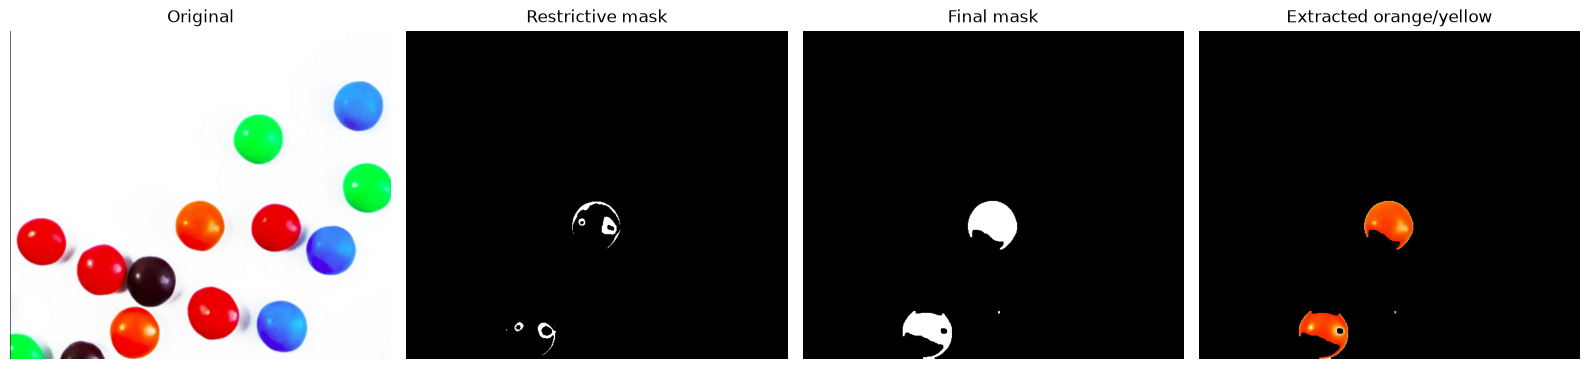

True

In [4]:
# Convert the image from BGR to HSV color space
hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)

# ------------------------------------------------------------
# Restrictive orange/yellow mask
# Intentionally narrow so that some valid target pixels are missed
# ------------------------------------------------------------
restrict = cv2.inRange(
    hsv,
    np.array([12, 180, 180]),
    np.array([18, 255, 255])
)

# ------------------------------------------------------------
# Improved/final orange-yellow mask
# Wider hue, saturation and brightness range
# ------------------------------------------------------------
final = cv2.inRange(
    hsv,
    np.array([5, 100, 100]),
    np.array([25, 255, 255])
)

# ------------------------------------------------------------
# Clean small isolated noise from the final mask
# ------------------------------------------------------------
kernel = np.ones((3, 3), np.uint8)

final = cv2.morphologyEx(
    final,
    cv2.MORPH_OPEN,
    kernel,
    iterations=1
)

final = cv2.morphologyEx(
    final,
    cv2.MORPH_CLOSE,
    kernel,
    iterations=2
)

# ------------------------------------------------------------
# Extract detected orange/yellow regions
# ------------------------------------------------------------
extracted_bgr = cv2.bitwise_and(
    bgr,
    bgr,
    mask=final
)

# Convert BGR to RGB for correct Matplotlib display
extracted_rgb = cv2.cvtColor(
    extracted_bgr,
    cv2.COLOR_BGR2RGB
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 4, figsize=(16, 4))

items = [
    ("Original", rgb),
    ("Restrictive mask", restrict),
    ("Final mask", final),
    ("Extracted orange/yellow", extracted_rgb)
]

for a, (title, image) in zip(ax, items):
    a.imshow(
        image,
        cmap="gray" if image.ndim == 2 else None
    )
    a.set_title(title)
    a.axis("off")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Save final mask
# ------------------------------------------------------------
cv2.imwrite(
    str(OUT / "task4_final_mask.png"),
    final
)

## Analysis
HSV separates hue from brightness/saturation better than raw intensity for color selection. The restrictive range misses valid target pixels because real object pixels vary due to lighting, highlights, shading and camera response. Final bounds: `H=20..35, S=100..255, V=100..255`.